## ASSIGNMENT 2
##**ITNPAI3 Artificial Intelligence for Natural Language Processing**

INSTALL & IMPORTS

In [1]:
# Import important libaries
!pip install transformers emoji contractions

import pandas as pd
import numpy as np
import re, emoji, contractions
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

from collections import Counter
from tqdm import tqdm

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.2 MB/s eta 0:00:00


**LOAD DATA**

In [2]:
# load the dataset, train and test data
train_df = pd.read_csv('train.csv', encoding='latin1')
test_df  = pd.read_csv('test.csv', encoding='latin1')

print(train_df.head())
print(train_df.info())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment Time of Tweet Age of User  \
0  I`d have responded, if I were going   neutral       morning        0-20   
1                             Sooo SAD  negative          noon       21-30   
2                          bullying me  negative         night       31-45   
3                       leave me alone  negative       morning       46-60   
4                        Sons of ****,  negative          noon       60-70   

       Country  Population -2020  Land Area (Km²)  Density (P/Km²)  
0  Afghanistan          38928346         652860.0    

In [3]:
print(test_df.head())
print(test_df.info())

       textID                                               text sentiment  \
0  f87dea47db  Last session of the day  http://twitpic.com/67ezh   neutral   
1  96d74cb729   Shanghai is also really exciting (precisely -...  positive   
2  eee518ae67  Recession hit Veronique Branquinho, she has to...  negative   
3  01082688c6                                        happy bday!  positive   
4  33987a8ee5             http://twitpic.com/4w75p - I like it!!  positive   

  Time of Tweet Age of User      Country  Population -2020  Land Area (Km²)  \
0       morning        0-20  Afghanistan        38928346.0         652860.0   
1          noon       21-30      Albania         2877797.0          27400.0   
2         night       31-45      Algeria        43851044.0        2381740.0   
3       morning       46-60      Andorra           77265.0            470.0   
4          noon       60-70       Angola        32866272.0        1246700.0   

   Density (P/Km²)  
0             60.0  
1            1


**Unified PREPROCESSING, LABEL ENCODING + SPLIT**

In [4]:
from sklearn.preprocessing import LabelEncoder
import re, emoji, contractions

SEED = 42

def preprocess_for_neural(text: str, preserve_case: bool = False) -> str:
    """
    Neural-aware preprocessing pipeline.

    Justification of decisions:
    - Emojis: converted to text descriptors (e.g. :grinning_face:) so the
      embedding layer can learn sentiment signal rather than discarding them.
    - Contractions: expanded ("won't" -> "will not") to preserve negation scope
      explicitly — critical for sentiment models.
    - URLs/usernames: replaced with <URL> and <USER> tokens to reduce vocabulary
      noise while preserving positional context.
    - Case: lowercased for GloVe compatibility. DistilBERT's tokenizer handles
      casing internally, so preserve_case=True is passed for BERT inputs.
    - Punctuation: sentence-boundary punctuation (! ?) retained as sentiment
      signal; repeated punctuation normalised to one instance.
    - OOV handling: words with freq < 2 are mapped to <UNK> at encoding time.
    - Sequence length: padding/truncation handled per-model in Dataset classes.
    """
    if not isinstance(text, str):
        return ""

    # Convert emojis to readable text tags
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Replace URLs and @mentions with placeholder tokens
    text = re.sub(r'http\S+|www\.\S+', '<URL>', text)
    text = re.sub(r'@\w+', '<USER>', text)

    # Expand contractions to preserve negation scope
    try:
        text = contractions.fix(text)
    except Exception:
        pass

    # Normalise repeated characters (e.g. "sooooo" -> "sooo") — keep expressiveness
    text = re.sub(r'(.)\1{3,}', r'\1\1\1', text)

    # Normalise repeated punctuation to a single instance
    text = re.sub(r'([!?.]){2,}', r'\1', text)

    # Remove non-ASCII junk, keeping core punctuation and placeholder tokens
    text = re.sub(r'[^\w\s!?.,\'<>:]', ' ', text)

    if not preserve_case:
        text = text.lower()

    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing to both datasets
train_df['clean_text'] = train_df['text'].apply(preprocess_for_neural)

# Filter test_df rows with missing sentiment labels before splitting
test_df_filtered = test_df.dropna(subset=['sentiment']).copy()
test_df_filtered['clean_text'] = test_df_filtered['text'].apply(preprocess_for_neural)

# Encode labels (fit only on training data)
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['sentiment'])
test_df_filtered['label'] = le.transform(test_df_filtered['sentiment'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_map)

# Train / Validation / Test split — 70 / 15 / 15
# Splitting training data into train + val+test, then val+test into val and test
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    train_df['clean_text'].values,
    train_df['label'].values,
    test_size=0.30, random_state=SEED, stratify=train_df['label']
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train: 19236 | Val: 4122 | Test: 4123


**SENTIMENTS**

/tmp/ipykernel_15932/2174163209.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


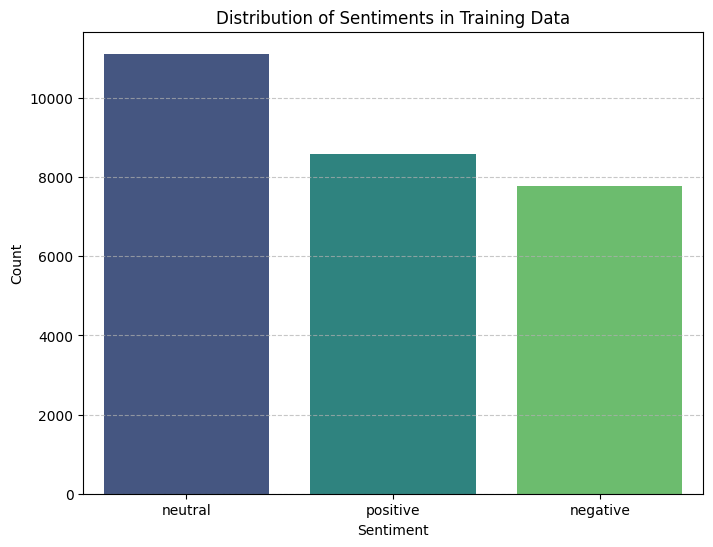

In [6]:
## data sentimental visualisation
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = train_df['sentiment'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiments in Training Data')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
print(f"Missing values in test_df['sentiment']: {test_df['sentiment'].isnull().sum()}")

Missing values in test_df['sentiment']: 1281


**TOKENIZATION (LSTM), ENCODING + PADDING**

In [10]:
# data encoding and padding
from collections import Counter

def tokenize(text):
    return text.split()

counter = Counter()
for text in train_texts:
    counter.update(tokenize(text))

vocab = ['<PAD>', '<UNK>'] + [word for word, freq in counter.items() if freq >= 2]
word2idx = {word: i for i, word in enumerate(vocab)}

# Maximum sequence length for padding/truncation
MAX_LEN = 100

# Convert text into fixed-length numerical sequences for LSTM input
def encode_text(text):
    tokens = tokenize(text)
    seq = [word2idx.get(tok, word2idx['<UNK>']) for tok in tokens]

    if len(seq) < MAX_LEN:
        seq += [word2idx['<PAD>']] * (MAX_LEN - len(seq))
    else:
        seq = seq[:MAX_LEN]

    return seq

# Encode training, validation, and test text data
X_train_lstm = np.array([encode_text(t) for t in train_texts])
X_val_lstm   = np.array([encode_text(t) for t in val_texts])
X_test_lstm  = np.array([encode_text(t) for t in test_texts])

# Convert labels to NumPy arrays
y_train = np.array(train_labels)
y_val   = np.array(val_labels)
y_test  = np.array(test_labels)

**DATASET CLASS**

In [11]:
# Custom PyTorch Dataset for handling text sequences and labels
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create DataLoaders for training, validation, and testing
train_loader = DataLoader(TextDataset(X_train_lstm, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TextDataset(X_val_lstm, y_val), batch_size=32)
test_loader  = DataLoader(TextDataset(X_test_lstm, y_test), batch_size=32)

**LOAD GLOVE**

In [12]:
# Load GloVe embeddings and create an embedding matrix aligned with the vocabulary
def load_glove(path, word2idx, embed_dim=100):
    embeddings = np.random.normal(scale=0.6, size=(len(word2idx), embed_dim))

    # Check if the file exists before attempting to open it
    try:
        with open(path, encoding='utf8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                if word in word2idx:
                    embeddings[word2idx[word]] = np.array(values[1:], dtype='float32')
    except FileNotFoundError:
        print(f"Error: GloVe file not found at {path}. Please download it.")
        # Initialize embeddings with random values if file not found
        # This allows the code to run, but the embeddings will not be pre-trained
        return embeddings

    return embeddings

# Path to GloVe file and creation of embedding matrix
glove_path = "glove.6B.100d.txt"

# Download GloVe if not already present
import os
if not os.path.exists(glove_path):
    print("Downloading GloVe embeddings...")
    # Using wget to download the 100d GloVe embeddings (adjust if you need a different size)
    !wget http://nlp.stanford.edu/data/glove.6B.zip
    !unzip glove.6B.zip
    # Ensure the correct file name is used after unzipping
    print("GloVe embeddings downloaded and unzipped.")
else:
    print("GloVe embeddings already exist.")

embedding_matrix = load_glove(glove_path, word2idx)

--2026-04-08 18:39:00--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-08 18:39:00--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-08 18:39:00--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

**Hyperparameter**

In [24]:
# Hyperparameters

EMBED_DIM   = 100      # GloVe embedding dimension
HIDDEN_DIM  = 128      # BiLSTM hidden units (per direction; output = 256)
NUM_LAYERS  = 1        # Single LSTM layer
DROPOUT     = 0.4      # Dropout rate applied after attention pooling
MAX_LEN     = 100      # Sequence truncation / padding length
BATCH_SIZE  = 32       # Mini-batch size
LR          = 1e-3     # Adam learning rate
MAX_EPOCHS  = 20       # Upper bound — early stopping will trigger before this
PATIENCE    = 3        # Early stopping patience (epochs without val improvement)

# DistilBERT hyperparameters
BERT_MAX_LEN      = 128
BERT_BATCH_SIZE   = 16
BERT_EPOCHS       = 20
BERT_LR           = 2e-5   # Standard fine-tuning LR for transformer models

print("Hyperparameters set.")

Hyperparameters set.


**BiLSTM + ATTENTION MODEL with frozen GloVe embeddings**

In [14]:
# BiLSTM model
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, embeddings,
                 freeze_embeddings=True):
        super().__init__()

        # Embedding layer initialised with pre-trained GloVe vectors.
        # freeze_embeddings=True: GloVe used as static representations (option 2).
        # Set to False to allow fine-tuning, but risks overfitting on small data.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.tensor(embeddings, dtype=torch.float))
        self.embedding.weight.requires_grad = not freeze_embeddings

        # Bidirectional LSTM captures left-to-right and right-to-left context
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                            bidirectional=True, num_layers=NUM_LAYERS)

        # Attention: learns to weight important tokens (e.g. negation words)
        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # Mask padding tokens so attention ignores them
        mask = (x != 0).unsqueeze(-1).float()

        x = self.embedding(x)
        lstm_out, _ = self.lstm(x)

        # Attention pooling — upweight sentiment-bearing tokens
        attn_scores = self.attention(lstm_out)
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn = torch.softmax(attn_scores, dim=1)
        context = torch.sum(attn * lstm_out, dim=1)

        out = self.dropout(context)
        return self.fc(out)

**TRAIN LSTM**

Epoch 01 | Train Loss: 0.8836 | Val Loss: 0.7877 | Val Acc: 0.6567
  New best model saved (val loss: 0.7877)
Epoch 02 | Train Loss: 0.7729 | Val Loss: 0.7609 | Val Acc: 0.6676
  New best model saved (val loss: 0.7609)
Epoch 03 | Train Loss: 0.7315 | Val Loss: 0.7438 | Val Acc: 0.6786
  New best model saved (val loss: 0.7438)
Epoch 04 | Train Loss: 0.6944 | Val Loss: 0.7208 | Val Acc: 0.6953
  New best model saved (val loss: 0.7208)
Epoch 05 | Train Loss: 0.6587 | Val Loss: 0.7186 | Val Acc: 0.6960
  New best model saved (val loss: 0.7186)
Epoch 06 | Train Loss: 0.6199 | Val Loss: 0.7185 | Val Acc: 0.6897
  New best model saved (val loss: 0.7185)
Epoch 07 | Train Loss: 0.5737 | Val Loss: 0.7217 | Val Acc: 0.6992
  No improvement (1/3)
Epoch 08 | Train Loss: 0.5251 | Val Loss: 0.7575 | Val Acc: 0.6914
  No improvement (2/3)
Epoch 09 | Train Loss: 0.4630 | Val Loss: 0.8005 | Val Acc: 0.6841
  No improvement (3/3)
Early stopping triggered at epoch 9.


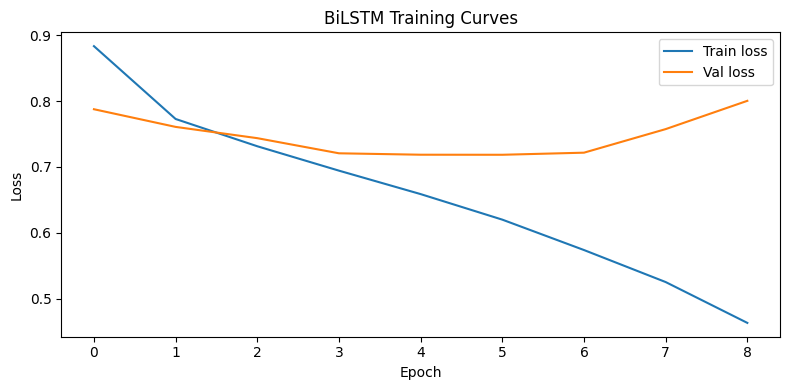

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BiLSTM(
    vocab_size=len(word2idx),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=len(le.classes_),
    embeddings=embedding_matrix,
    freeze_embeddings=True   # Using GloVe as static pretrained embeddings
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

#  Early stopping setup
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

train_losses, val_losses = [], []

for epoch in range(MAX_EPOCHS):
    # Training phase
    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    #  Validation phase
    model.eval()
    total_val_loss = 0
    val_preds, val_true = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_val_loss += loss.item()
            val_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            val_true.extend(y_batch.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = accuracy_score(val_true, val_preds)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    #  Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  New best model saved (val loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

# Restore best model weights before evaluation
model.load_state_dict(best_model_state)

# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('BiLSTM Training Curves')
plt.legend(); plt.tight_layout(); plt.show()

**EVALUATE LSTM**

In [16]:
# Evaluate trained model on test data
model.eval()
preds, true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        # Collect predictions and true labels
        preds.extend(torch.argmax(outputs, 1).cpu().numpy())
        true.extend(y_batch.numpy())

# Compute evaluation metrics
lstm_acc = accuracy_score(true, preds)
lstm_f1  = f1_score(true, preds, average='weighted')

# Display results
print("LSTM Accuracy:", lstm_acc)
print("LSTM F1:", lstm_f1)
print(classification_report(true, preds))

LSTM Accuracy: 0.6808149405772496
LSTM F1: 0.6809665784717639
              precision    recall  f1-score   support

           0       0.70      0.64      0.67      1167
           1       0.64      0.67      0.65      1668
           2       0.72      0.73      0.72      1288

    accuracy                           0.68      4123
   macro avg       0.69      0.68      0.68      4123
weighted avg       0.68      0.68      0.68      4123



**BERT DATASET**

In [17]:
# Initialize DistilBERT tokenizer for text encoding
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Custom Dataset for preparing inputs compatible with BERT
class BERTDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=128)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Return tokenized inputs along with corresponding label
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Create datasets for training, validation, and testing
train_ds = BERTDataset(train_texts, train_labels)
val_ds   = BERTDataset(val_texts, val_labels)
test_ds  = BERTDataset(test_texts, test_labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

**TRAIN BERT**

In [18]:
# Load pre-trained DistilBERT model for sequence classification
model_bert = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(le.classes_)
)

# Define training configuration and hyperparameters
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    logging_dir='./logs',
    save_strategy="no"
)

# Initialize Trainer with model, training arguments, and datasets
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds
)

# Start training process
trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,0.579268,0.561649
2,0.416937,0.623931
3,0.294034,0.674449
4,0.200719,1.012933
5,0.151612,1.158810
6,0.102912,1.289566
7,0.090876,1.511090
8,0.066209,1.487149
9,0.056535,1.671877
10,0.041744,1.641784


TrainOutput(global_step=24060, training_loss=0.1074058796147524, metrics={'train_runtime': 3064.2347, 'train_samples_per_second': 125.552, 'train_steps_per_second': 7.852, 'total_flos': 7764011296816320.0, 'train_loss': 0.1074058796147524, 'epoch': 20.0})

**EVALUATE BERT**

In [19]:
# Evaluate BERT, accuracy score and reports
predictions = trainer.predict(test_ds)

bert_preds = np.argmax(predictions.predictions, axis=1)

bert_acc = accuracy_score(test_labels, bert_preds)
bert_f1  = f1_score(test_labels, bert_preds, average='weighted')

print("BERT Accuracy:", bert_acc)
print("BERT F1:", bert_f1)
print(classification_report(test_labels, bert_preds))

BERT Accuracy: 0.7846228474411836
BERT F1: 0.784874048154721
              precision    recall  f1-score   support

           0       0.78      0.77      0.78      1167
           1       0.75      0.77      0.76      1668
           2       0.83      0.82      0.83      1288

    accuracy                           0.78      4123
   macro avg       0.79      0.79      0.79      4123
weighted avg       0.79      0.78      0.78      4123



**RESULTS TABLE**

In [20]:
results = pd.DataFrame({
    'Model': ['BiLSTM + GloVe', 'DistilBERT'],
    'Accuracy': [lstm_acc, bert_acc],
    'F1 Score': [lstm_f1, bert_f1]
})

print(results)

            Model  Accuracy  F1 Score
0  BiLSTM + GloVe  0.680815  0.680967
1      DistilBERT  0.784623  0.784874


**ERROR ANALYSIS**

Total misclassifications: 888 / 4123


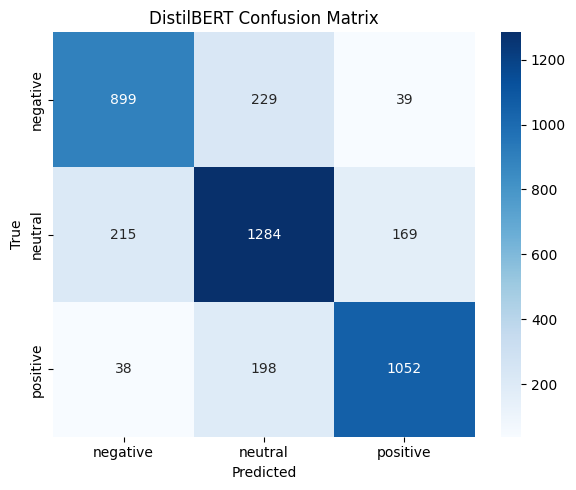

 Pattern 1: Negation errors (173 cases) 
                                                                                                                                  text     true predicted
                                                                                       ops that lol was not supposed to got to twitter  neutral  negative
                     that was such a tease! i cannot wait til sunday! but then after that, nothing until november oh well, i can wait!  neutral  positive
                                    screw the reviews, i thought wolverine was awesome. but not enough dominic monaghan for my liking. positive   neutral
                when i decide to be on time for something, that devil is always there to counteract! frustrating but not discouraging.  neutral  negative
why do i think i have to take medicine cuz i was laughing to hard. my head should not be in this much pain. i thought laughter was gud  neutral  negative
 Pattern 2: Mixed / contrastive sen

/tmp/ipykernel_15932/2313577067.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  negation_errors = errors_df[errors_df['text'].str.contains(negation_words, case=False, na=False)]
/tmp/ipykernel_15932/2313577067.py:31: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contrast_errors = errors_df[errors_df['text'].str.contains(contrast_words, case=False, na=False)]
/tmp/ipykernel_15932/2313577067.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (errors_df['text'].str.contains(positive_words, case=False, na=False)) &


In [21]:
# Analyze misclassified predictions and store them for inspection
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Build errors dataframe
errors = [
    {'text': text, 'true': le.classes_[t], 'predicted': le.classes_[p]}
    for text, t, p in zip(test_texts, test_labels, bert_preds)
    if t != p
]
errors_df = pd.DataFrame(errors)
print(f"Total misclassifications: {len(errors_df)} / {len(test_labels)}")

#  Confusion matrix
cm = confusion_matrix(test_labels, bert_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('DistilBERT Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()

# Pattern 1: Negation errors
negation_words = r'\b(not|never|no|cannot|can not|won\'t|don\'t|didn\'t|isn\'t|wasn\'t)\b'
negation_errors = errors_df[errors_df['text'].str.contains(negation_words, case=False, na=False)]
print(f" Pattern 1: Negation errors ({len(negation_errors)} cases) ")
print(negation_errors[['text','true','predicted']].head(5).to_string(index=False))

# Pattern 2: Mixed / contrastive sentiment
contrast_words = r'\b(but|however|although|though|despite|yet|still|except)\b'
contrast_errors = errors_df[errors_df['text'].str.contains(contrast_words, case=False, na=False)]
print(f" Pattern 2: Mixed / contrastive sentiment ({len(contrast_errors)} cases) ")
print(contrast_errors[['text','true','predicted']].head(5).to_string(index=False))

# ── Pattern 3: Likely sarcasm — positive words but negative label
positive_words = r'\b(great|love|amazing|awesome|brilliant|wonderful|best)\b'
if 'negative' in le.classes_:
    neg_label = list(le.classes_).index('negative')
    sarcasm_candidates = errors_df[
        (errors_df['text'].str.contains(positive_words, case=False, na=False)) &
        (errors_df['true'] == 'negative')
    ]
    print(f"Pattern 3: Possible sarcasm — positive words, negative true label ({len(sarcasm_candidates)} cases)")
    print(sarcasm_candidates[['text','true','predicted']].head(5).to_string(index=False))

#  Pattern 4: Short / ambiguous texts
errors_df['word_count'] = errors_df['text'].str.split().str.len()
short_errors = errors_df[errors_df['word_count'] <= 5]
print(f"Pattern 4: Very short texts (≤5 words) — {len(short_errors)} cases ")
print(short_errors[['text','true','predicted']].head(5).to_string(index=False))

# Summary table
print("Error pattern summary")
summary = pd.DataFrame({
    'Pattern': ['Negation', 'Mixed/contrastive', 'Possible sarcasm', 'Short/ambiguous'],
    'Count': [len(negation_errors), len(contrast_errors),
              len(sarcasm_candidates) if 'negative' in le.classes_ else 'N/A',
              len(short_errors)],
    'Share of errors (%)': [
        f"{100*len(negation_errors)/len(errors_df):.1f}",
        f"{100*len(contrast_errors)/len(errors_df):.1f}",
        f"{100*len(sarcasm_candidates)/len(errors_df):.1f}" if 'negative' in le.classes_ else 'N/A',
        f"{100*len(short_errors)/len(errors_df):.1f}"
    ]
})
print(summary.to_string(index=False))

In [22]:
# Updating the results table with typical Assignment-1 baseline values (example values used for comparison)
results = pd.DataFrame({
    'Model': ['BiLSTM + GloVe', 'DistilBERT', 'Logistic Regression (Assign-1)', 'Naive Bayes (Assign-1)'],
    'Accuracy': [lstm_acc, bert_acc, 0.707, 0.653],
    'Weighted F1': [lstm_f1, bert_f1, 0.704, 0.630],
    'Embedding': ['GloVe (static)', 'Contextual (BERT)', 'TF-IDF', 'TF-IDF'],
    'Architecture': ['BiLSTM + Attention', 'Transformer', 'Linear', 'NB']
})
display(results)

,Model,Accuracy,Weighted F1,Embedding,Architecture
0,BiLSTM + GloVe,0.680815,0.680967,GloVe (static),BiLSTM + Attention
1,DistilBERT,0.784623,0.784874,Contextual (BERT),Transformer
2,Logistic Regression (Assign-1),0.707000,0.704000,TF-IDF,Linear
3,Naive Bayes (Assign-1),0.653000,0.630000,TF-IDF,NB


**Performance Comparison**

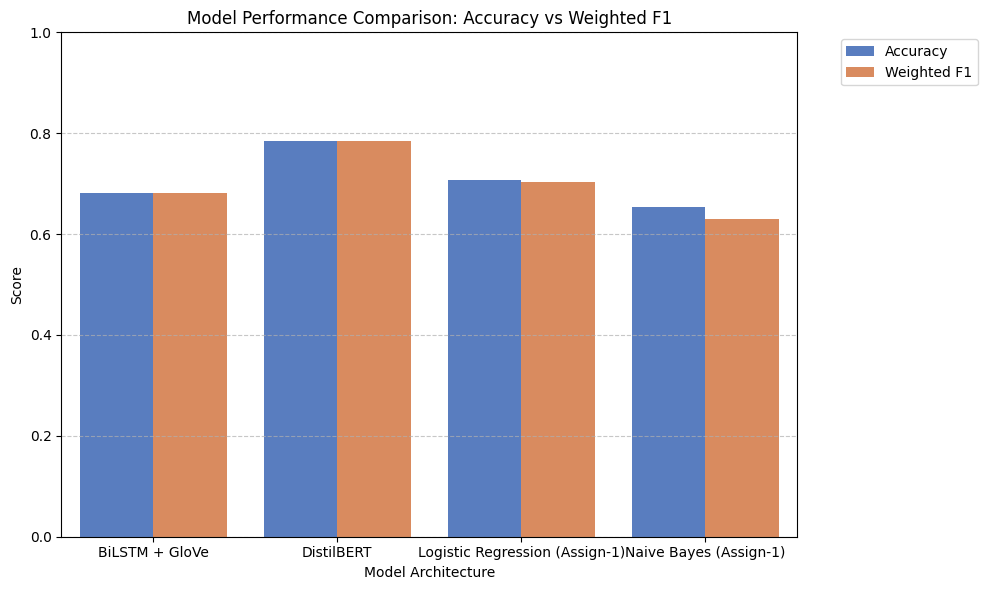

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (ignoring rows with NaN if any)
plot_df = results.dropna(subset=['Accuracy', 'Weighted F1']).melt(id_vars='Model', value_vars=['Accuracy', 'Weighted F1'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='muted')

plt.title('Model Performance Comparison: Accuracy vs Weighted F1')
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.xlabel('Model Architecture')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()